In [30]:
import zipfile
import os

zip_path = "/content/Resume.zip"        # your zip file
extract_path = "extracted"  # folder to extract

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP file extracted successfully!")

ZIP file extracted successfully!


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv("/content/extracted/Resume.csv")

In [33]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [34]:
df.isnull().sum()

,0
ID,0
Resume_str,0
Resume_html,0
Category,0


In [35]:
df['Category'].unique()

array(['HR', 'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE',
       'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE',
       'BPO', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'AUTOMOBILE',
       'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT',
       'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION'],
      dtype=object)

In [36]:
df.shape

(2484, 4)

In [37]:
df['Category'].value_counts()

,count
Category,
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,120
ADVOCATE,118
CHEF,118
ENGINEERING,118
ACCOUNTANT,118
FINANCE,118
FITNESS,117
AVIATION,117


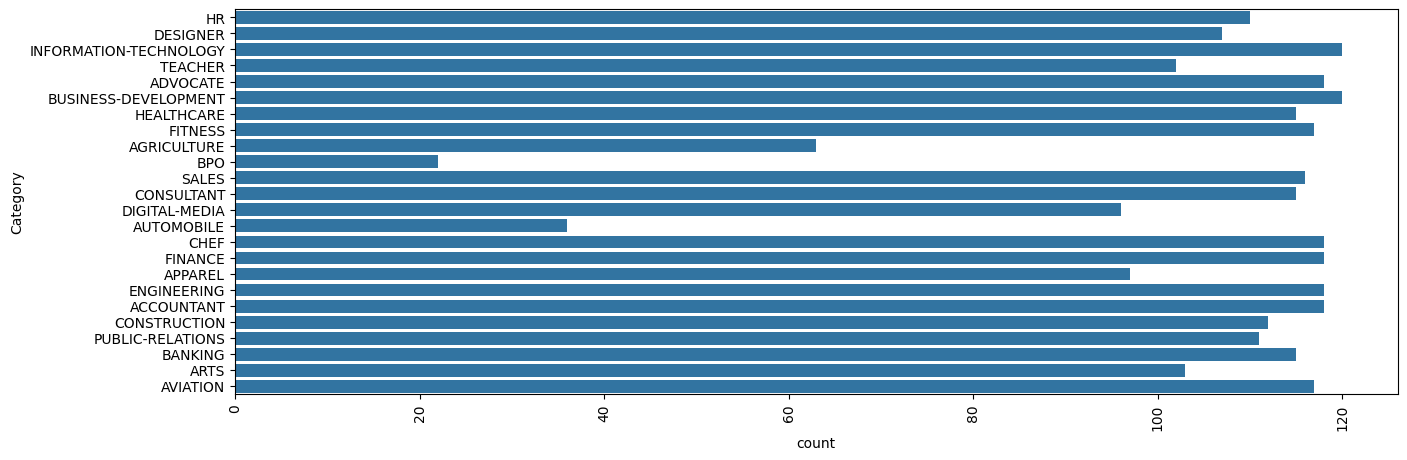

In [38]:
plt.figure(figsize=(15,5))
sns.countplot(df['Category'])
plt.xticks(rotation=90)
plt.show()

In [39]:
df['Resume_str'][0]

"         HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss pr

In [40]:
import re
def cleanResume(txt):
    cleanText = re.sub('http\S+\s', ' ', txt)
    cleanText = re.sub('RT|cc', ' ', cleanText)
    cleanText = re.sub('#\S+\s', ' ', cleanText)
    cleanText = re.sub('@\S+', '  ', cleanText)
    cleanText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', cleanText)
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText)
    cleanText = re.sub('\s+', ' ', cleanText)
    return cleanText

<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\]'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\]'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_8758/3739445999.py:3: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('http\S+\s', ' ', txt)
/tmp/ipykernel_8758/3739445999.py:5: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('#\S+\s', ' ', cleanText)
/tmp/ipykernel_8758/3739445999.py:6: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('@\S+', '  ', cleanText)
/tmp/ipykernel_8758/3739445999.py:7: SyntaxWarning: invalid escape sequence '\]'
  cleanText = re.sub('[%s]' % re.escape

In [41]:
cleanResume("my #### $ #  #noorsaeed webiste like is this http://heloword and access it @gmain.com")

'my webiste like is this and a ess it '

In [42]:
df['Resume_str'] = df['Resume_str'].apply(lambda x: cleanResume(x))

In [43]:
df['Resume_str'][0]

' HR ADMINISTRATOR MARKETING ASSOCIATE HR ADMINISTRATOR Summary Dedicated Customer Service Manager with 15 years of experience in Hospitality and Customer Service Management Respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service Highlights Focused on customer satisfaction Team management Marketing savvy Conflict resolution techniques Training and development Skilled multi tasker Client relations specialist A omplishments Missouri DOT Supervisor Training Certification Certified by IHG in Customer Loyalty and Marketing by Segment Hilton Worldwide General Manager Training Certification A omplished Trainer for cross server hospitality systems such as Hilton OnQ Micros Opera PMS Fidelio OPERA Reservation System ORS Holidex Completed courses and seminars in customer service sales strategies inventory control loss prevention safety time management leadership and performance assessment Experience HR Administrator Marketing

In [44]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [45]:
df['Category'] = le.fit_transform(df['Category'])

In [46]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR MARKETING ASSOCIATE HR ADMIN...,"<div class=""fontsize fontface vmargins hmargin...",19
1,22323967,HR SPECIALIST US HR OPERATIONS Summary Versat...,"<div class=""fontsize fontface vmargins hmargin...",19
2,33176873,HR DIRECTOR Summary Over 20 years experience ...,"<div class=""fontsize fontface vmargins hmargin...",19
3,27018550,HR SPECIALIST Summary Dedicated Driven and Dy...,"<div class=""fontsize fontface vmargins hmargin...",19
4,17812897,HR MANAGER Skill Highlights HR SKILLS HR Depa...,"<div class=""fontsize fontface vmargins hmargin...",19


In [47]:
df['Category'].unique()

array([19, 13, 20, 23,  1,  9, 18, 17,  2,  8, 22, 12, 14,  5, 10, 16,  3,
       15,  0, 11, 21,  7,  4,  6])

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words = 'english')

In [49]:
tfidf.fit(df['Resume_str'])
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words='english',
    min_df=2,
    max_df=0.9
)

X = tfidf.fit_transform(df['Resume_str'])

In [50]:
df

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR MARKETING ASSOCIATE HR ADMIN...,"<div class=""fontsize fontface vmargins hmargin...",19
1,22323967,HR SPECIALIST US HR OPERATIONS Summary Versat...,"<div class=""fontsize fontface vmargins hmargin...",19
2,33176873,HR DIRECTOR Summary Over 20 years experience ...,"<div class=""fontsize fontface vmargins hmargin...",19
3,27018550,HR SPECIALIST Summary Dedicated Driven and Dy...,"<div class=""fontsize fontface vmargins hmargin...",19
4,17812897,HR MANAGER Skill Highlights HR SKILLS HR Depa...,"<div class=""fontsize fontface vmargins hmargin...",19
...,...,...,...,...
2479,99416532,RANK SGT E 5 NON COMMISSIONED OFFICER IN CHAR...,"<div class=""fontsize fontface vmargins hmargin...",6
2480,24589765,GOVERNMENT RELATIONS COMMUNICATIONS AND ORGAN...,"<div class=""fontsize fontface vmargins hmargin...",6
2481,31605080,GEEK SQUAD AGENT Professional Profile IT supp...,"<div class=""fontsize fontface vmargins hmargin...",6
2482,21190805,PROGRAM DIRECTOR OFFICE MANAGER Summary Highl...,"<div class=""fontsize fontface vmargins hmargin...",6


In [51]:
from sklearn.model_selection import train_test_split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, df['Category'], test_size=0.2, random_state=42)

In [54]:
X_train.shape

(1987, 10000)

In [55]:
X_test.shape
#

(497, 10000)

In [56]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
knn = KNeighborsClassifier()
rf = RandomForestClassifier(n_estimators=100)
knn.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier()

In [57]:
y_pred = knn.predict(X_test)
y_pred1 = rf.predict(X_test)

In [58]:
print(accuracy_score(y_test, y_pred))
print(accuracy_score(y_test, y_pred1))

0.5110663983903421
0.7545271629778671


In [59]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("LR Accuracy:", accuracy_score(y_test, y_pred))

LR Accuracy: 0.6458752515090543


In [60]:
import pickle

def save_model(model, vectorizer, filename="model.pkl"):
    data = {
        "model": model,
        "vectorizer": vectorizer
    }

    with open(filename, "wb") as f:
        pickle.dump(data, f)

    print("Model saved successfully!")

In [61]:
def load_model(filename="model.pkl"):
    with open(filename, "rb") as f:
        data = pickle.load(f)

    print("Model loaded successfully!")
    return data["model"], data["vectorizer"]

In [62]:
save_model(model, tfidf, "resume_model.pkl")

Model saved successfully!


In [63]:
model, tfidf = load_model("resume_model.pkl")

Model loaded successfully!


In [64]:
# Create TF-IDF
tfidf = TfidfVectorizer(max_features=10000)
X = tfidf.fit_transform(df['Resume_str'])

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X, df['Category'])

# Save BOTH
save_model(model, tfidf, "resume_model.pkl")

Model saved successfully!


In [65]:
def predict_resume(text, model, vectorizer):
    cleaned = cleanResume(text)
    vector = vectorizer.transform([cleaned])
    prediction = model.predict(vector)
    return prediction[0]

# Example
predict_resume("i am a business owner", model, tfidf)

np.int64(12)